# Evaluation Charts

Reads the two CSVs produced by `step6_benchmark.ipynb` and renders comparison charts. All charts use the same friendly labels:

- **Operation:** Category Summary · Find Popular Listings · Top 10 per Category · Keyword Search · Add Seller Stats
- **Library:** Pandas · Polars · Multiprocessing · PySpark

| § | Chart                       | File                         |
|---|-----------------------------|------------------------------|
| 2 | Time (seconds)              | `fig_workload_time.png`      |
| 3 | Records per second          | `fig_workload_throughput.png`|
| 4 | Peak memory used            | `fig_workload_memory.png`    |
| 5 | CPU utilisation             | `fig_workload_cpu.png`       |
| 6 | How many times faster than Pandas | `fig_speedup_heatmap.png`|

---
## 0. Setup

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS = 'workload_results.csv'
RUNS    = 'workload_runs.csv'

LIBRARY_ORDER   = ['Pandas', 'Polars', 'Multiprocessing', 'PySpark']
OPERATION_ORDER = ['Category Summary', 'Find Popular Listings', 'Top 10 per Category',
                   'Keyword Search', 'Add Seller Stats']

sns.set_theme(style='whitegrid', context='notebook')

---
## 1. Load results

In [14]:
results = pd.read_csv(RESULTS)
results['Library']   = pd.Categorical(results['Library'],   LIBRARY_ORDER,   ordered=True)
results['Operation'] = pd.Categorical(results['Operation'], OPERATION_ORDER, ordered=True)
results = results.sort_values(['Operation', 'Library']).reset_index(drop=True)
results

,Operation,Library,Time (s),CPU (%),Peak Memory (MB),Process Memory (MB),Records Returned,Throughput
0,Category Summary,Pandas,5.367620,99.625437,17.112334,266.269531,881.0,3.699258e+04
1,Category Summary,Polars,0.108797,438.897839,0.061716,458.839844,881.0,1.891678e+06
2,Category Summary,Multiprocessing,4.232416,353.961840,63.441278,505.210156,881.0,4.688845e+04
3,Category Summary,PySpark,1.490190,196.559786,0.197959,507.046875,881.0,1.340459e+05
4,Find Popular Listings,Pandas,0.022914,177.790771,1.449798,508.210938,23276.0,8.674908e+06
5,Find Popular Listings,Polars,0.083242,491.033677,0.057437,488.025781,23276.0,2.384424e+06
6,Find Popular Listings,Multiprocessing,2.088312,524.918671,9.936091,476.844531,23276.0,9.510720e+04
7,Find Popular Listings,PySpark,1.167787,156.783420,0.111511,476.111719,23276.0,1.702669e+05
8,Top 10 per Category,Pandas,0.157499,121.200396,29.165210,477.328906,1363.0,1.274425e+06
9,Top 10 per Category,Polars,0.130930,467.331032,0.065631,601.075781,1363.0,1.535717e+06


In [15]:
runs = pd.read_csv(RUNS)
runs['Library']   = pd.Categorical(runs['Library'],   LIBRARY_ORDER,   ordered=True)
runs['Operation'] = pd.Categorical(runs['Operation'], OPERATION_ORDER, ordered=True)
runs = runs.sort_values(['Operation', 'Library', 'Run #']).reset_index(drop=True)
runs.head()

,Operation,Library,Run #,Time (s),CPU (%),Peak Memory (MB),Process Memory (MB),Records Returned,Throughput
0,Category Summary,Pandas,1,5.376483,100.844277,17.676441,266.246094,881,36906.843147
1,Category Summary,Pandas,2,5.637127,98.398966,16.971744,266.292969,881,35200.375908
2,Category Summary,Pandas,3,5.292341,98.904725,16.971715,266.296875,881,37493.617900
3,Category Summary,Pandas,4,5.248915,99.425315,16.970365,266.250000,881,37803.814949
4,Category Summary,Pandas,5,5.283236,100.553903,16.971408,266.261719,881,37558.231357


In [16]:
def grouped_bar(metric: str, title: str, fname: str, palette: str = 'Set2', logy: bool = False) -> None:
    """Render an Operation × Library grouped bar chart and save as PNG."""
    fig, ax = plt.subplots(figsize=(11, 5))
    sns.barplot(
        data=results, x='Operation', y=metric, hue='Library',
        ax=ax, palette=palette, order=OPERATION_ORDER, hue_order=LIBRARY_ORDER,
    )
    ax.set_title(f'{title} — average of 5 runs')
    ax.set_ylabel(metric + (' (log scale)' if logy else ''))
    ax.set_xlabel('')
    if logy:
        ax.set_yscale('log')
    ax.legend(title='Library', bbox_to_anchor=(1.02, 1), loc='upper left')
    for p in ax.patches:
        h = p.get_height()
        if h is not None and not np.isnan(h):
            ax.annotate(f'{h:.2f}', (p.get_x() + p.get_width() / 2, h),
                        ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

---
## 2. Time taken (lower is better)

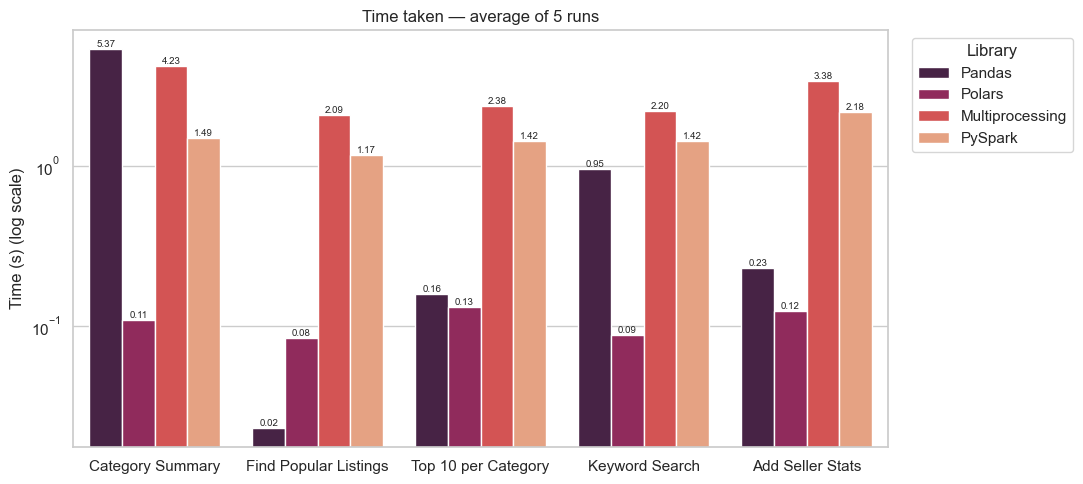

In [17]:
grouped_bar('Time (s)', 'Time taken', 'fig_workload_time.png', palette='rocket', logy=True)

---
## 3. Records processed per second (higher is better)

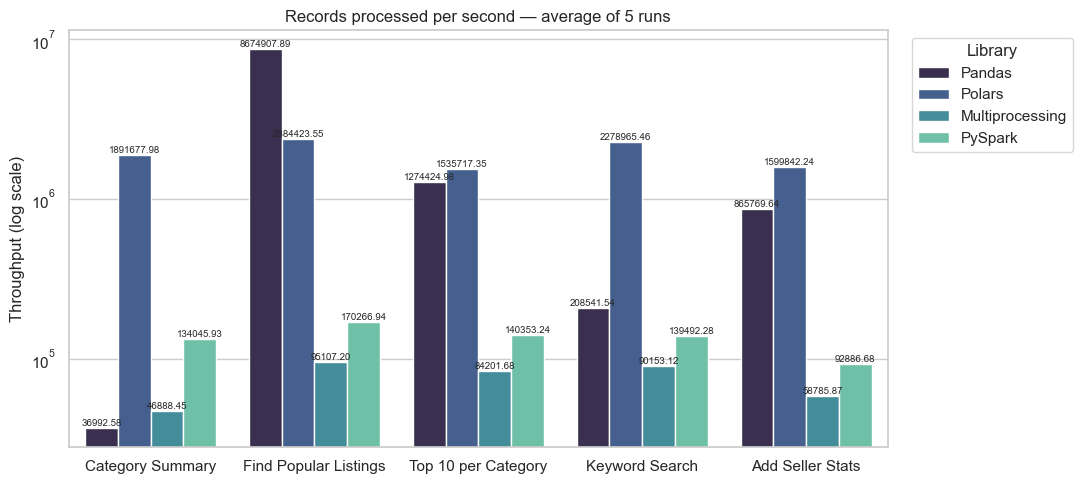

In [18]:
grouped_bar('Throughput', 'Records processed per second', 'fig_workload_throughput.png', palette='mako', logy=True)

---
## 4. Peak memory used (lower is better)

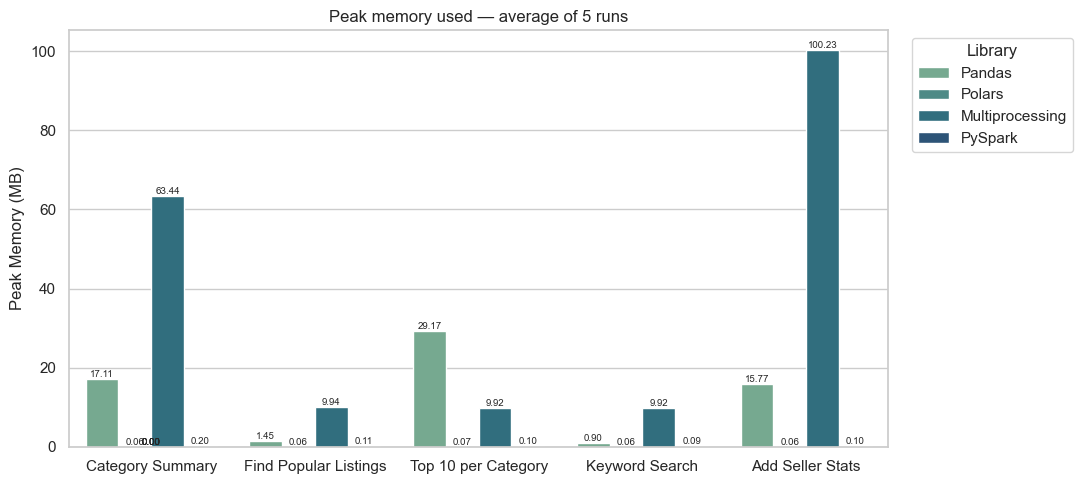

In [19]:
grouped_bar('Peak Memory (MB)', 'Peak memory used', 'fig_workload_memory.png', palette='crest')

---
## 5. CPU utilisation

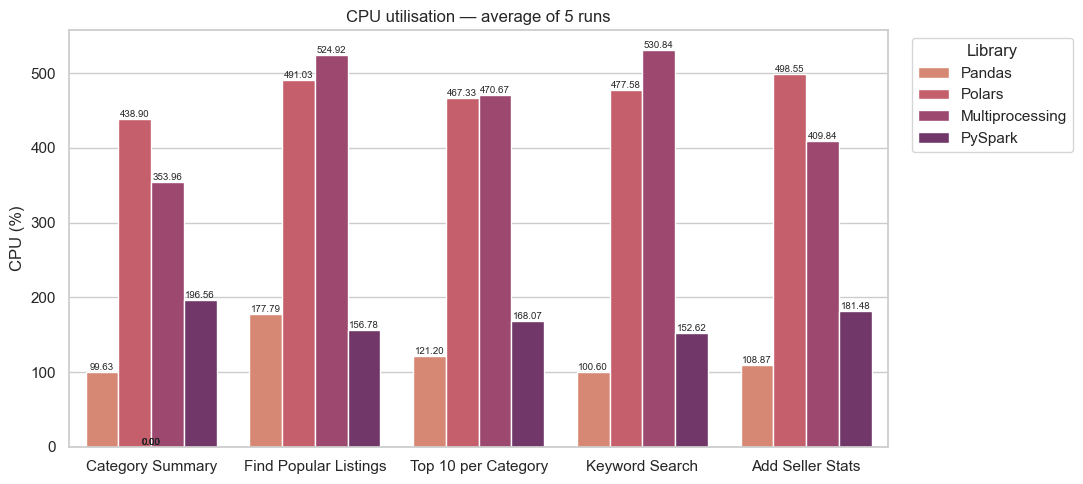

In [20]:
grouped_bar('CPU (%)', 'CPU utilisation', 'fig_workload_cpu.png', palette='flare')

---
## 6. How many times faster than Pandas

Each cell shows **Pandas time ÷ this library's time** for that operation.
- **Green / above 1.0:** faster than Pandas (e.g. 5.0 = five times faster).
- **Red / below 1.0:** slower than Pandas.

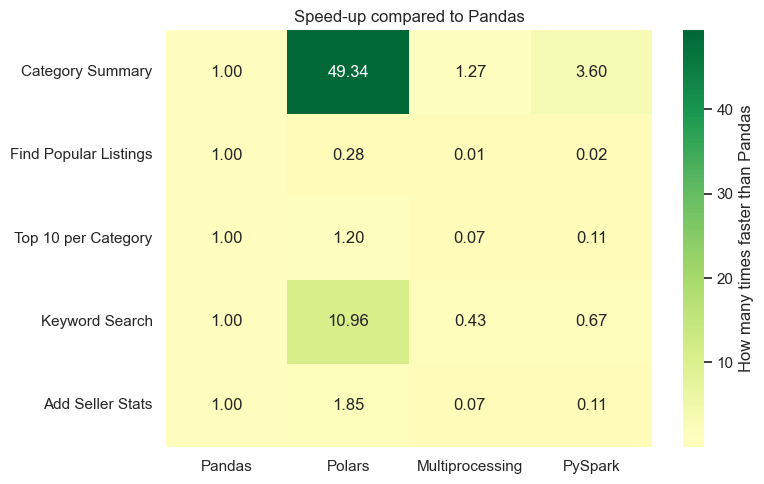

Library,Pandas,Polars,Multiprocessing,PySpark
Operation,,,,
Category Summary,1.0,49.34,1.27,3.60
Find Popular Listings,1.0,0.28,0.01,0.02
Top 10 per Category,1.0,1.20,0.07,0.11
Keyword Search,1.0,10.96,0.43,0.67
Add Seller Stats,1.0,1.85,0.07,0.11


In [21]:
pivot = results.pivot(index='Operation', columns='Library', values='Time (s)')
pivot = pivot.reindex(index=OPERATION_ORDER, columns=LIBRARY_ORDER)
speedup = pd.DataFrame(
    pivot['Pandas'].values[:, None] / pivot.values,
    index=pivot.index, columns=pivot.columns,
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    speedup, annot=True, fmt='.2f', cmap='RdYlGn', center=1.0, ax=ax,
    cbar_kws={'label': 'How many times faster than Pandas'},
)
ax.set_title('Speed-up compared to Pandas')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('fig_speedup_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

speedup.round(2)

---
## 8. Interpretation in plain language

- **Category Summary / Find Popular Listings** — Polars is usually the fastest because it groups and filters data using all CPU cores at once. PySpark is slower here only because it spends time starting up its engine, which is wasted on a dataset this small.
- **Top 10 per Category** — sorting is heavy work; Polars and PySpark both finish well ahead of Pandas. Multiprocessing helps Pandas because each core can sort its own slice.
- **Keyword Search** — this shows the biggest gap. Pandas has to check each row's text in Python one at a time, while Polars and PySpark process the whole column in optimised code.
- **Add Seller Stats** — joining two tables is where PySpark catches up: it uses a broadcast-join trick that scales well. Multiprocessing pays a small cost moving the seller-stats table to each worker.
